# Final Project: Rabbit Adoption in British Columbia

This dataset contains rabbit records (n= 1,807) from shelters in British Columbia, Canada from 2017-2021.
The data are obtained from ShelterBuddy, a tracking database used by the shelters in BC.
Factors include rabbit breed, primary coat color, length of stay and date of birth.  


## Data Dictionary

| Variable | Type | Description |
|--------|---------|--------|
|Animal ID |numeric|Unique identification number for each rabbit|
|Animal Type |categorical|Animal type|
|Source |categorical|How the animal came into the shelter's care|
|Source Date |datetime|The date the rabbit came to the shelter   |
|Intake Region |  categorical  |  Location of shelter |
|Surrender Reason|  categorical  | Reported reason for surrender  |
|Status Date | datetime   | The date the rabbit left the shelter  |
|Status |   categorical | Outcome of time at shelter |
|Outcome Eval Cat | categorical   |  Short code for outcum status  |
|Primary Breed |  categorical  | Primary breed of the rabbit  |
|Primary Color |  categorical  | Primary color of the rabbit  |
|Gender |  categorical  |  Gender of the rabbit |
|DOB | datetime   | Rabbit's date of birth |
|Age Years | numerical   |  The rabbit's age (years)* |
|Age Months| numerical  | The additional months of the rabbit's age * |

*These columns are unsuable due to bad coding. Figure age from DOB instead

Columns added during data cleaning and analysis:

| Variable | Type | Description |
|--------|---------|--------|
|color_group|categorical|Simplified grouping of rabbit coat colors|
|breed_group |categorical|Simplified grouping of rabbit breeds|
|location |categorical|Cleanded and simplified location to use as joining key |
|LatDD|numeric|Latitude in degrees|
|LongDD|numeric|Longitude in degrees|
|Total Days* |numeric|Total days the rabbit was in the shelter|
|Excluded Days* |numeric|Days excluded from total stay calculation|
|LOS* |numeric|Length of the rabbit's stay in the shelter, in days|
|Age(years)* |numeric|Rabbit's age at intake|

*These columns joined from U. et al.'s additional dataset, as they had more access to ShelterBuddy data that included days excluded due to youth of the rabbit, or other factors.


In [ ]:
#Libraries  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re   
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point


In [16]:
#Importing dataset
df = pd.read_csv("https://raw.githubusercontent.com/Hildeburh/164Files/refs/heads/main/BCRabbits.csv")
df.head()

,Animal ID,Animal Type,Source,Source Date,Intake Region,Surrender Reason,Status Date,Status,Outcome Eval Cat,Primary Breed,Primary Color,Gender,DOB,Age Years,Age Months
0,398253,Rabbit,Humane Officer Seized,03/15/2016 21:47,Cruelty Investigations Department,NaN,01/08/2017 13:08,Euthanized by Offsite Vet,UU,New Zealand,White,Male,03/15/2015,1.0,9.0
1,399447,Rabbit,Stray,03/31/2016 10:49,Vancouver Branch,NaN,01/17/2017 15:47,Adopted Altered,H,American,Ruby Eyed White,Female,02/17/2016,6.0,10.0
2,400783,Rabbit,Shelter Offspring,04/16/2016 11:39,Kamloops & District Branch,NaN,04/10/2017 16:09,Adopted Altered,H,New Zealand,White,Female,04/16/2016,6.0,8.0
3,399449,Rabbit,Stray,03/31/2016 10:49,Vancouver Branch,NaN,01/17/2017 15:47,Adopted Altered,H,American,Black,Female,02/17/2016,6.0,10.0
4,400780,Rabbit,Shelter Offspring,04/16/2016 11:39,Kamloops & District Branch,NaN,01/15/2017 16:08,Adopted Altered,H,New Zealand,White,Female,04/16/2016,6.0,8.0


# Scope of Analysis & Data Cleaning

## Data Cleaning - Color
This factor needs cleaning, as the original dataset had dozens of color varieties.  This cleaning makes the data more accessible to analysis.

Major tasks:  
1. clean the entries - remove whitespace and make all lower-case
2. create a function that sorts the many different color options into seven (6 plus other) categories.
3. create a bar graph that visually shows the counts of each color set in the dataset
4. spend way too much time figuring out how to get each bar to be the color of the rabbit's coat.



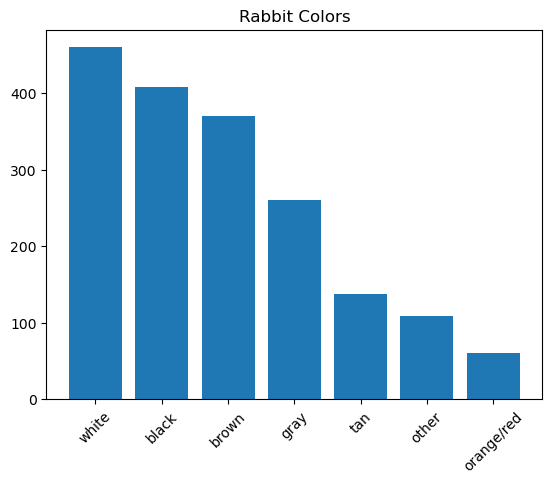

In [17]:
#Figuring out the messiness:
df.groupby("Primary Color").size()

#Cleaning color entries
def clean_color(s):
    if pd.isna(s):
        return s
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", " ", s)   # remove punctuation
    s = re.sub(r"\s+", " ", s)      # collapse spaces
    return s

df['rabbit_color_clean'] = df['Primary Color'].apply(clean_color)

#Creating saner color groups
def color_group(s):
    if pd.isna(s):
        return np.nan
    if "black" in s:
        return "black"
    if "white" in s:
        return "white"
    if any(x in s for x in ["brown", "chocolate", "sable"]):
        return "brown"
    if any(x in s for x in ["gray", "grey", "lilac", "blue", "seal", "sliver", "smoke"]):
        return "gray"
    if any(x in s for x in ["tan", "fawn", "beige"]):
        return "tan"
    if any(x in s for x in ["orange", "red", "gold"]):
        return "orange/red"
    return "other"

df["color_group"] = df["rabbit_color_clean"].apply(color_group)
color_counts = df["color_group"].value_counts()

plt.bar(color_counts.index, color_counts.values)
plt.xticks(rotation=45)
plt.title("Rabbit Colors")
plt.show()



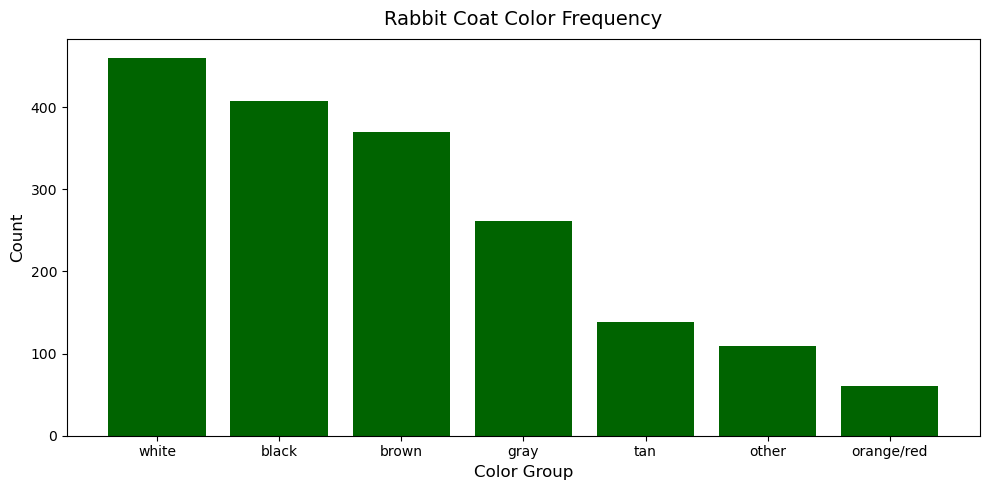

In [59]:
#making it look nicer
color_counts = color_counts.sort_values(ascending=False)

plt.figure(figsize=(10,5))  # wider figure
plt.bar(color_counts.index, color_counts.values, color = "darkgreen")

plt.title("Rabbit Coat Color Frequency", fontsize=14, pad=10)
plt.xlabel("Color Group", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()                    # fixes spacing issues
plt.show()

/var/folders/f5/v46p410559q3l4d2k22gwx700000gn/T/ipykernel_3058/368187560.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


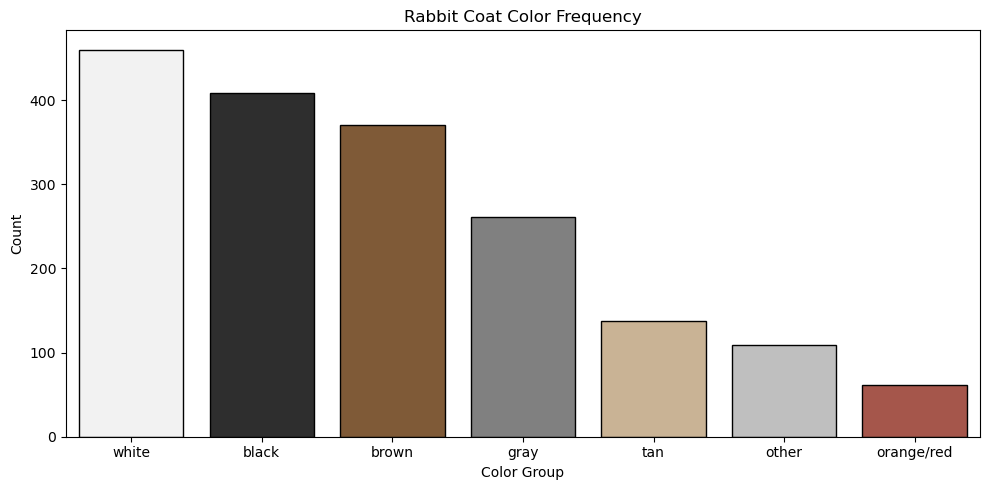

In [61]:

#getting fancy with colors to reflect rabbit color
rabbit_palette = {
    "black": "#2E2E2E",
    "white": "#F2F2F2",
    "brown": "#8B5A2B",
    "grey": "#A9A9A9",
    "tan": "#D2B48C",
    "orange/red": "#B44A3C",
    "other": "#bfbfbf"
}

palette = [rabbit_palette.get(color, "#808080") for color in color_counts.index]

plt.figure(figsize=(10,5))
sns.barplot(
    x=color_counts.index,
    y=color_counts.values,
    palette=palette,
    edgecolor='black'
)

plt.title("Rabbit Coat Color Frequency")
plt.xlabel("Color Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Data Cleaning - Breed
In this section, I'm using a similar method as above to reduce the number of breeds.  I first clean the data, lowercase it, and then sort it into 11 (10 plus other) groups.  I then graphed it as a bar chart; I didn't take the time to make this one as pretty... 

In [62]:

#Creating saner breed groups
def breed_group(s):
    if pd.isna(s):
        return np.nan
    s = str(s).lower()  
    if "lop" in s:
        return "lop"
    if "american" in s:
        return "american"
    if "angora" in s:
        return "angora"
    if "giant" in s:
        return "giant"
    if "dutch" in s:
        return "dutch"
    if "lionhead" in s:
        return "lionhead"
    if any(x in s for x in ["californian", "himalayan"]):
        return "californian"
    if any(x in s for x in ["dwarf", "polish", "hotot"]):
        return "dwarf"
    if any(x in s for x in ["rex", "fox"]):
        return "rex"
    if any(x in s for x in ["new zealand", "florida white"]):
        return "new zealand"
    return "other"
df['breed_group'] = df['Primary Breed'].apply(breed_group)


df.groupby("breed_group").size()




breed_group
american       669
angora          42
californian     95
dutch          303
dwarf          233
giant           69
lionhead       335
lop            315
new zealand     67
other          150
rex            324
dtype: int64

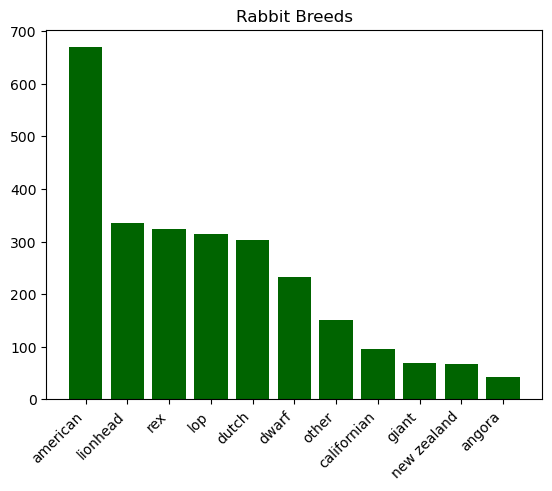

In [67]:
#simple graph
df["breed_group"] = df["Primary Breed"].apply(breed_group)
breed_counts = df["breed_group"].value_counts()

plt.bar(breed_counts.index, breed_counts.values, color = "darkgreen")
plt.xticks(rotation=45, ha='right')
plt.title("Rabbit Breeds")
plt.show()

## Adding latitude and longitude for shelter locations.
I wanted to be able to map the locations.  First I cleaned the location data by removing the word "District" and "Branch" to get the Canadian city names.  Then I used that data as the join key to match it with a dataset of lat/long coodinates I obtained from the Canadian government (https://open.canada.ca/data/en/dataset/d92224ee-03ef-4904-be53-b677d8e01ac4). I had high hopes for creating a heatmap of rabbit shelter populations in BC, but Python's geopandas was being really unusable, so I just made it in R instead (see below).

In [20]:
df.groupby("Intake Region").size()

Intake Region
Abbotsford Branch                              169
Alberni-Clayoquot Branch                        18
Burnaby Branch                                 103
Campbell River Branch                           39
Chilliwack Branch                              161
Comox Valley & District Branch                  40
Cowichan & District Branch                      25
Cruelty Investigations Department               20
East Kootenay Branch                            98
Haida Gwaii Branch                               5
Kamloops & District Branch                      86
Kelowna Branch                                  62
Maple Ridge Branch                             125
Nanaimo & District Branch                       18
Nelson Branch                                   13
North Cariboo District Branch                   37
North Peace Branch                              21
Parksville-Qualicum Beach & District Branch     16
Powell River & District Branch                  68
Prince Rupert Bra

In [21]:
#Loading in location data lat/long
bclocdf = pd.read_csv("/Users/hildeburh/Dropbox/~Coursework/~CIS 164/Project/bc-gazetteer-2025-11-13.csv")

#Cleaning the rabbit dataframe data
df["location"] = (
    df["Intake Region"]
    .str.lower()
    .str.removesuffix(" branch")
    .str.removesuffix(" & district")
    .str.strip()
)

#Cleaning the location data
bclocdf["location"] = (
    bclocdf["Official Name"]
    .str.lower()
)

#Adding in the latitute/longitute data with a left join, key column = location
merged = df.merge(
    bclocdf[["location", "Latitude","Longitude", "LatDD", "LongDD"]],
    on="location",
    how="left")

merged.head()
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal ID           2442 non-null   int64  
 1   Animal Type         2442 non-null   object 
 2   Source              2442 non-null   object 
 3   Source Date         2442 non-null   object 
 4   Intake Region       2442 non-null   object 
 5   Surrender Reason    902 non-null    object 
 6   Status Date         2442 non-null   object 
 7   Status              2442 non-null   object 
 8   Outcome Eval Cat    2434 non-null   object 
 9   Primary Breed       2442 non-null   object 
 10  Primary Color       2442 non-null   object 
 11  Gender              2440 non-null   object 
 12  DOB                 2318 non-null   object 
 13  Age Years           2318 non-null   float64
 14  Age Months          2318 non-null   float64
 15  rabbit_color_clean  2442 non-null   object 
 16  color_

## Making a map of shelter locations
So... I could NOT get geopandas to load/work/install.  So the map I used in my presentation was made in R.  Here's the code if you're interested!  

`ggplot() +`
  `borders("world", regions = "Canada",`
          `fill = NA, colour = "grey60") +`
  
  `stat_bin2d(`
    `data = merged,`
    `aes(x = LongDD, y = LatDD),`
    `bins = 150`
  `) +`
  
  `coord_quickmap(`
    `xlim = range(merged$LongDD, na.rm = TRUE) + c(-1, 1),`
    `ylim = range(merged$LatDD,  na.rm = TRUE) + c(-1, 1)`
  `) +`
  
  `scale_fill_viridis_c(name = "Count") +`
  `labs(`
    `title = "Density of Rabbit Shelter Populations in British Columbia",`
    `x = "Longitude",`
   ` y = "Latitude"`
  `) +`
  `theme_void()`

## Joining additional data from U. et al. 
This is a published article using the dataset I found.  (Location: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0300633). They had slightly more access to the ShelterBuddy database data than I did, so I used their calculations for length of stay and age.  Since it was the same dataset, I was able to join on the unique rabbit ID number.

In [68]:
#Loading additional data from U. et al. 
df_supp = pd.read_csv("https://raw.githubusercontent.com/Hildeburh/164Files/refs/heads/main/Supp_Rabbit_Data.csv")


#Joining in data from U. et al. Using a left join on key column Animal ID
merged_supp = merged.merge(
    df_supp[["Animal ID", "Total Days", "Excluded Days", "LOS", "Age (years)"]],
    on="Animal ID",
    how="left")

merged_supp.info()
merged_supp.to_csv('rabbit_data.csv', index=False) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2786 entries, 0 to 2785
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal ID           2786 non-null   int64  
 1   Animal Type         2786 non-null   object 
 2   Source              2786 non-null   object 
 3   Source Date         2786 non-null   object 
 4   Intake Region       2786 non-null   object 
 5   Surrender Reason    1004 non-null   object 
 6   Status Date         2786 non-null   object 
 7   Status              2786 non-null   object 
 8   Outcome Eval Cat    2778 non-null   object 
 9   Primary Breed       2786 non-null   object 
 10  Primary Color       2786 non-null   object 
 11  Gender              2784 non-null   object 
 12  DOB                 2660 non-null   object 
 13  Age Years           2660 non-null   float64
 14  Age Months          2660 non-null   float64
 15  rabbit_color_clean  2786 non-null   object 
 16  color_

# Data Analysis

The major thing I'm interested in is the rabbit's length of stay at a shelter, and what factors, if any, are a reliable predictor of that stay length.  I first analyzed the factor "LOS" (length of stay) and found it very right skewed, with a lot of outliers on the upper bound.  This indicated to me that while most rabbits had a short stay at the shelter, there were some that had much longer stays.  


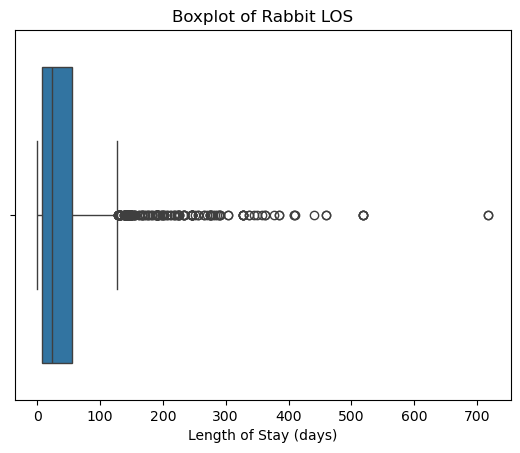

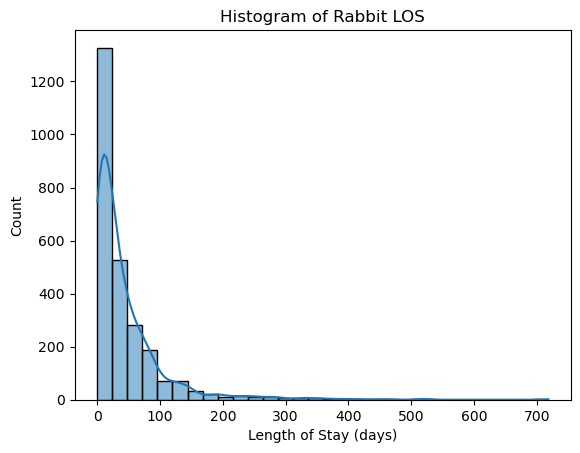

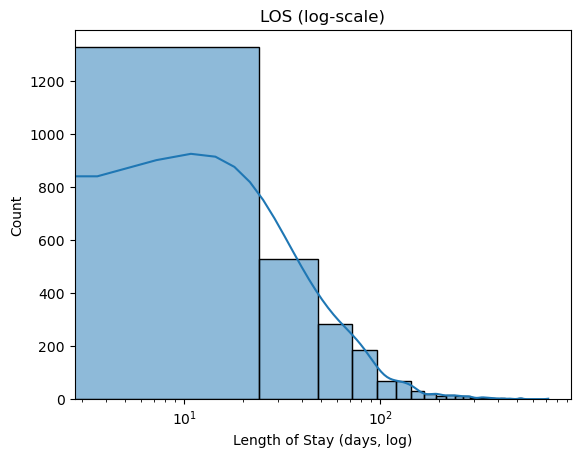

In [ ]:
#Analyzing Length of Stay (LOS)

import seaborn as sns
import matplotlib.pyplot as plt

#boxplot
sns.boxplot(x=merged_supp['LOS'])
plt.title("Boxplot of Rabbit LOS")
plt.xlabel("Length of Stay (days)")
plt.show()

#histogram
sns.histplot(merged_supp['LOS'], bins=30, kde=True)
plt.title("Histogram of Rabbit LOS")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Count")
plt.show()

#log values
sns.histplot(merged_supp['LOS'], bins=30, kde=True)
plt.xscale('log')
plt.title("LOS (log-scale)")
plt.xlabel("Length of Stay (days, log)")
plt.ylabel("Count")
plt.show()


## Model: Random Forest Regressor

The publised paper with this dataset uses a multilinear regression model with t-tests on each factor to obtain p-values that they used to determine strenght of influence.  Factors they identified that had impact were the rabbit's age, the breed size, and month in which they were admitted.  Factors that had little influece were coat color, sex, and ear type (lop or non-lop).  Since this analysis exists, it was more interesting to me to see if another method of analysis would show similar data.  Therefore, I ran a machine-learning algorithm (from sci-kit Learn), specifically Random Forest Regressor.  This is a good model for several reasons, but mostly because it's good for highly skewed data with a lot of categorical data.  That's basically my dataset.  I chose to do the regressor version rather than the classifier version because my target (LOS) is numeric, and this would enable my model to predict a length of stay for any new data after training.  

In [ ]:
#Running Random Forest Regressor on target LOS
#Creating the dataframe with features and target

features = [
    "Source",
    "Surrender Reason",
    "Status",
    "Outcome Eval Cat",
    "Gender",
    "Age (years)",
    "color_group",
    "breed_group",
    "location"
]

#changing LOS to log due to heavy right skew
merged_supp["LOS_log"] = np.log1p(merged_supp["LOS"])

#building dataframe
df_model = merged_supp[features + ["LOS_log"]].copy()

#fixing missing values
cat_cols = df_model.select_dtypes(include="object").columns
df_model[cat_cols] = df_model[cat_cols].fillna("Unknown")
df_model = df_model.dropna(subset=["LOS_log"])


In [40]:
#Split and encode data for Random Forest Regressor
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model["LOS_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

# Align test set columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

#Train the RF Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [41]:
#Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")

MAE:  0.70 days
RMSE: 0.99 days


Interpretation of MAE: the model guesses length of stay within .7 days.  

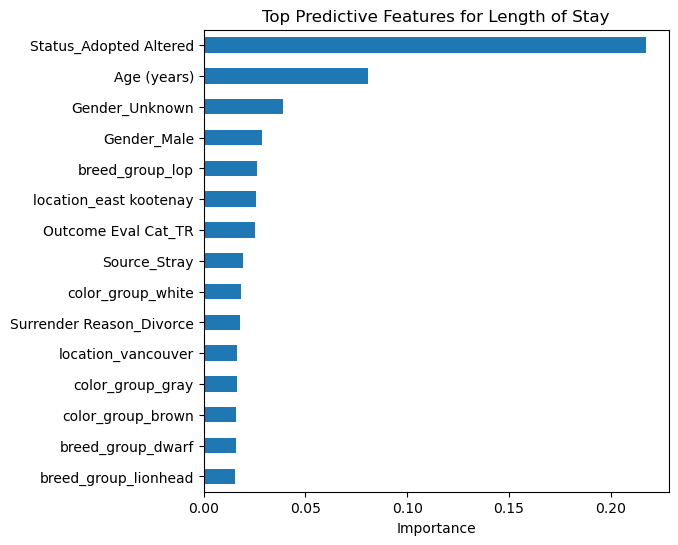

In [42]:
#Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_feats = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6,6))
top_feats.plot(kind="barh")
plt.title("Top Predictive Features for Length of Stay")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

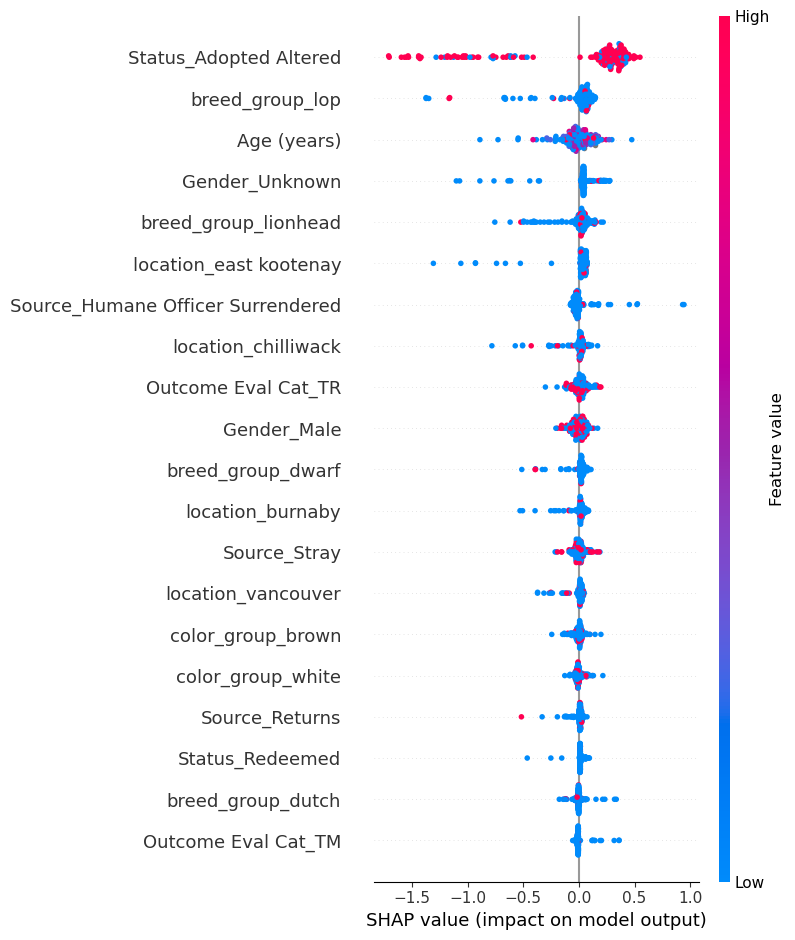

In [44]:
#SHAP analysis
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train.sample(200))  # subset for speed
shap.summary_plot(shap_values, X_train.sample(200))

### First and second pass included data leakage
So, my analsys of this first pass is that there was significant data leakage in the status factor, so for the next version, I'll remove that and run it a second time.  I'll run it a third time to remove the Outcome Eval Cat(egory) becasue that also was causing leakage and the model not considering other factors in its decision-making process.  

In [46]:
#dropping status for a better analysis of the data

#Make a copy to be safe
df = merged_supp.copy()

#Keep only rows that have a LOS value
df = df[df["LOS"].notna()]

#Create log-transformed target
df["LOS_log"] = np.log1p(df["LOS"])

#Define features (without Status)
features = [
    "Source",
    "Surrender Reason",
    "Outcome Eval Cat",
    "Gender",
    "Age (years)",
    "color_group",
    "breed_group",
    "location"
]

#Build modeling dataframe with features + target
df_model = df[features + ["LOS_log"]].copy()

#Fix missing categoricals
cat_cols = df_model.select_dtypes(include="object").columns
df_model[cat_cols] = df_model[cat_cols].fillna("Unknown")

#Drop any rows where the target is still missing, just in case
df_model = df_model.dropna(subset=["LOS_log"])

#Final X and y
X = df_model[features]
y = df_model["LOS_log"]

print("NaNs in y?", y.isna().sum())  # should print 0


NaNs in y? 0


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

# Align test set columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

#Train the RF Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
#Evaluate model
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")

MAE:  0.75 days
RMSE: 1.05 days


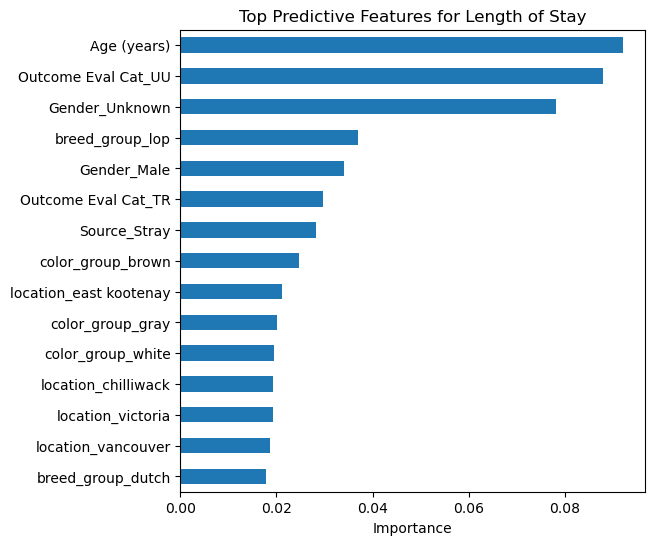

In [49]:
#Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_feats = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6,6))
top_feats.plot(kind="barh")
plt.title("Top Predictive Features for Length of Stay")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Let's drop Outcome Eval Cat -- I think it's causing data leakage

#Make another copy to be safe
df = merged_supp.copy()

#Keep only rows that have a LOS value
df = df[df["LOS"].notna()]

#Create log-transformed target
df["LOS_log"] = np.log1p(df["LOS"])

#Define features (without Status)
features = [
    "Source",
    "Surrender Reason",
    "Gender",
    "Age (years)",
    "color_group",
    "breed_group",
    "location"
]

#Build modeling dataframe with features + target
df_model = df[features + ["LOS_log"]].copy()

#Fix missing categoricals
cat_cols = df_model.select_dtypes(include="object").columns
df_model[cat_cols] = df_model[cat_cols].fillna("Unknown")

#Drop any rows where the target is still missing, just in case
df_model = df_model.dropna(subset=["LOS_log"])

#Final X and y
X = df_model[features]
y = df_model["LOS_log"]

print("NaNs in y?", y.isna().sum())  # should print 0

NaNs in y? 0


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

# Align test set columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

#Train the RF Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [52]:
#Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")

MAE:  0.80 days
RMSE: 1.09 days


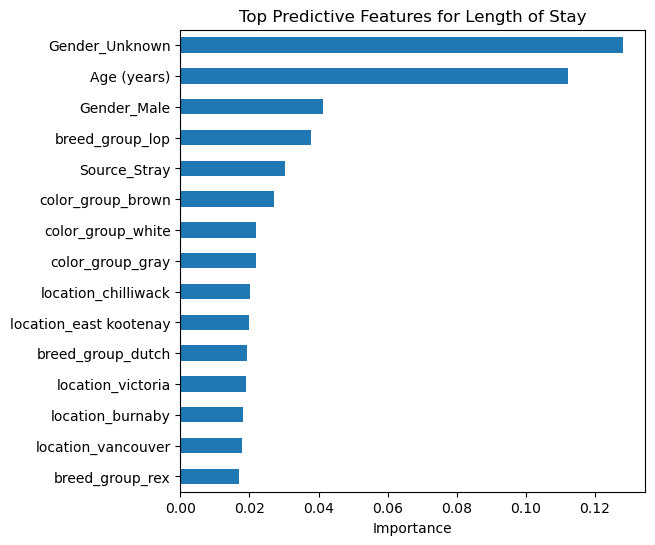

In [53]:
#Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_feats = feature_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6,6))
top_feats.plot(kind="barh")
plt.title("Top Predictive Features for Length of Stay")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

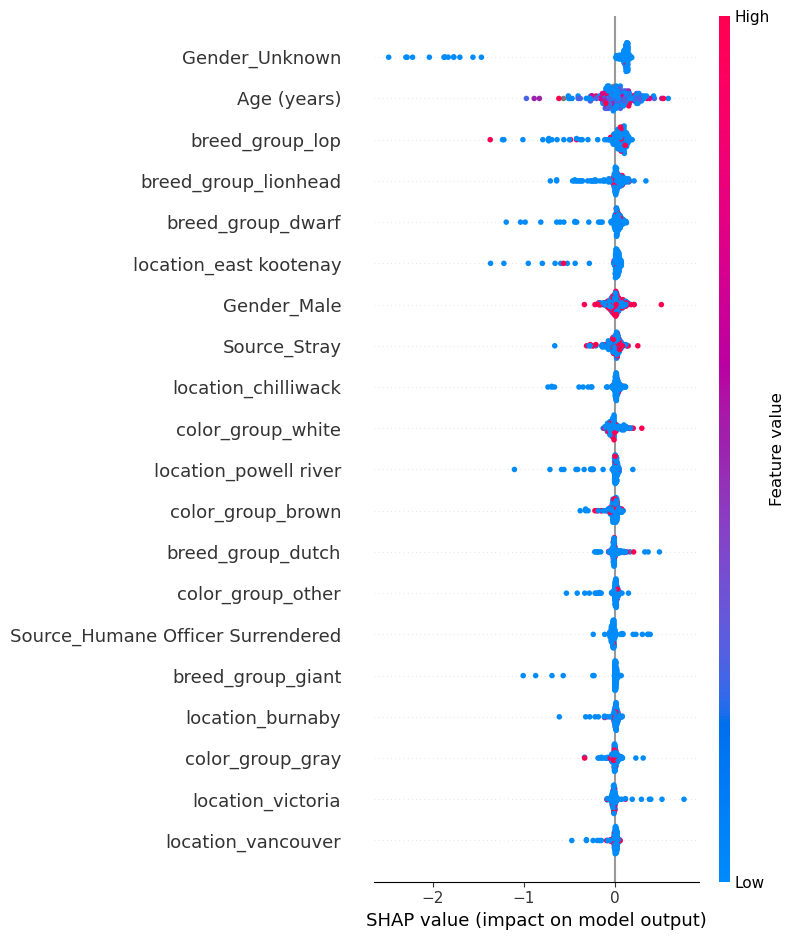

In [ ]:
#SHAP analysis w/subset for speed
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train.sample(200)) 
shap.summary_plot(shap_values, X_train.sample(200))

In conlucion -- while the SHAP analysis here doesn't show a huge factor impact, it's interesting that there is some difference from the published study.  Specifically - the influence of lop breed places higher in this model than in the MLR model.  

## Final Step - Use Marley's stats to run a prediction with this model
Adding the code to use the model to predict the stay for a rabbit, if they were in this system.

In [74]:
#Marley's stats 
marley = {
    "Source": "Owner Surrender",
    "Surrender Reason": "Unknown",
    "Gender": "F",
    "Age (years)": 5.0,
    "color_group": "black",
    "breed_group": "american",
    "location": "Unknown"
}   

# Convert to DataFrame
new_df = pd.DataFrame([marley])

# Apply the same transformations as training
new_df = pd.get_dummies(new_df, drop_first=True)
new_df = new_df.reindex(columns=X_train.columns, fill_value=0)

#run the prediction
pred = rf.predict(new_df)
print("Estimated time in shelter (days):", pred[0])

#Uncertainty estimates

Estimated time in shelter (days): 3.4760171059238245


# Results
Both the MLR (from U. et al., see reference below and the RF models see the age of the rabbit as a leading indicator of their time in shelter.

The RF model saw gender and ear type (lop/non-lop) as more influential compared to the MLR model.

Both models indicated that coat color was not a reliable predictor of time in shelter.  


# References

2024 Statistics. (2024). Shelter Animals Count. Retrieved December 6, 2025, from https://www.shelteranimalscount.org/explore-the-data/statistics-2024/

Cook, A. J., & McCobb, E. (2012). Quantifying the Shelter Rabbit Population: An Analysis of Massachusetts and Rhode Island Animal Shelters. Journal of 
Applied Animal Welfare Science, 15(4), 297–312. https://doi.org/10.1080/10888705.2012.709084

DeMello, M. (2016). Rabbits Multiplying Like Rabbits: The Rise in the Worldwide Popularity of Rabbits as Pets. In M. P. Pręgowski (Ed.), Companion 

Animals in Everyday Life: Situating Human-Animal Engagement within Cultures (pp. 91–107). Palgrave Macmillan US. https://doi.org/10.1057/978-1-137-59572-0_7

Ellis, C. F., McCormick, W., & Tinarwo, A. (2017). Analysis of Factors Relating to Companion Rabbits Relinquished to Two United Kingdom Rehoming Centers. Journal of Applied Animal Welfare Science, 20(3), 230–239. https://doi.org/10.1080/10888705.2017.1303381

Glasser, C. L. (2024). “The 21st Century Rabbit Paradox”: Attitudes Toward and Experiences with Rabbits in the United States. Society & Animals, 32(3), 287–308. https://doi.org/10.1163/15685306-bja10100

Kavlocoglu, E. (2021, October 20). What Is Random Forest? | IBM. https://www.ibm.com/think/topics/random-forest
Shelter Animals Count. (n.d.). [Video recording]. Retrieved December 6, 2025, from https://www.facebook.com/shelteranimalscount/posts/-february-is-adopt-a-rescued-rabbit-month-as-we-wrap-up-the-month-to-celebrate-h/645736767845114/

Tinga, C. (2025). Bunny Bonds and Shelter Stories: Understanding Human-Rabbit Relationships and Recent Trends in Managing Unwanted Companion Rabbits [University of Guelph]. https://hdl.handle.net/10214/28788

U, A. S. Y., Hou, C. Y., & Protopopova, A. (2024). Rabbit intakes and predictors of their length of stay in animal shelters in British Columbia, Canada. PLOS ONE, 19(4), e0300633. https://doi.org/10.1371/journal.pone.0300633

Updated Rabbit Statistics: How Many Pet Rabbits are There in the USA? (2025, September 19). https://rabbit.org/resources/how-many-pet-rabbits-are-there-in-the-usa/

U.S. pet ownership statistics | American Veterinary Medical Association. (n.d.). Retrieved December 6, 2025, from https://www.avma.org/resources-tools/reports-statistics/us-pet-ownership-statistics

## Datasets
U, A. S. Y., Hou, C. Y., & Protopopova, A. (2024). Rabbit intakes and predictors of their length of stay in animal shelters in British Columbia, Canada. PLOS ONE, 19(4), e0300633. https://doi.org/10.1371/journal.pone.0300633

Columbia, G. of B. (n.d.). BC Gazetteer—Open Government Portal. Retrieved December 9, 2025, from https://open.canada.ca/data/en/dataset/d92224ee-03ef-4904-be53-b677d8e01ac4


## Additional training

Codecademy Course: Machine Learning: Random Forests & Decision Trees.  https://www.codecademy.com/enrolled/courses/machine-learning-random-forests-decision-trees